<h1>ABIOLA PEACE EMMANUEL</h1>
<h2>MODULE : BIG DATA AND DATA MINING</h2>

<H2>Importing all required libaries</H2>

In [62]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

<h2>Reading in the dataset to start cleaning </h2>

In [11]:
DB = "accident_data_v1.0.0_2023 (1).db"

conn = sqlite3.connect(DB)

acc = pd.read_sql_query("SELECT * FROM accident;", conn)
veh = pd.read_sql_query("SELECT * FROM vehicle;", conn)
cas = pd.read_sql_query("SELECT * FROM casualty;", conn)

acc.head(), veh.head(), cas.head()

(  accident_index  accident_year accident_reference  location_easting_osgr  \
 0  2017010001708           2017          010001708               532920.0   
 1  2017010009342           2017          010009342               526790.0   
 2  2017010009344           2017          010009344               535200.0   
 3  2017010009348           2017          010009348               534340.0   
 4  2017010009350           2017          010009350               533680.0   
 
    location_northing_osgr  longitude   latitude  police_force  \
 0                196330.0  -0.080107  51.650061             1   
 1                181970.0  -0.173845  51.522425             1   
 2                181260.0  -0.052969  51.514096             1   
 3                193560.0  -0.060658  51.624832             1   
 4                187820.0  -0.072372  51.573408             1   
 
    accident_severity  number_of_vehicles  ...  \
 0                  1                   2  ...   
 1                  3           

<h2>STEP 2 — Check Missing Values</h2>

In [12]:
#🔹 2.1 Check missing values in accident table
acc.isna().sum().sort_values(ascending=False).head(20)
#🔹 2.2 Check missing values in vehicle table
veh.isna().sum().sort_values(ascending=False).head(20)
#🔹 2.3 Check missing values in casualty table
cas.isna().sum().sort_values(ascending=False).head(20)

casualty_index                        0
casualty_severity                     0
casualty_home_area_type               0
casualty_type                         0
pedestrian_road_maintenance_worker    0
bus_or_coach_passenger                0
car_passenger                         0
pedestrian_movement                   0
pedestrian_location                   0
age_band_of_casualty                  0
accident_index                        0
age_of_casualty                       0
sex_of_casualty                       0
casualty_class                        0
casualty_reference                    0
vehicle_reference                     0
accident_reference                    0
accident_year                         0
casualty_imd_decile                   0
dtype: int64

In [13]:
# Convert time to proper datetime
acc["time_parsed"] = pd.to_datetime(
    acc["time"],
    format="%H:%M",
    errors="coerce"   # sets bad formats to NaT
)

# Extract hour
acc["hour"] = acc["time_parsed"].dt.hour

# Count how many remained invalid
acc["hour"].isna().sum()

np.int64(0)

In [14]:
def clean_age(series):
    # Valid ages: 1 to 119
    return series.apply(lambda x: x if pd.notna(x) and x > 0 and x < 120 else np.nan)

# Clean driver age
veh["age_of_driver_clean"] = clean_age(veh["age_of_driver"])

# Clean vehicle age
veh["age_of_vehicle_clean"] = clean_age(veh["age_of_vehicle"])

# Clean casualty age
cas["age_of_casualty_clean"] = clean_age(cas["age_of_casualty"])

veh[["age_of_driver", "age_of_driver_clean"]].head(10)


,age_of_driver,age_of_driver_clean
0,24,24.0
1,19,19.0
2,33,33.0
3,40,40.0
4,-1,NaN
5,35,35.0
6,31,31.0
7,37,37.0
8,29,29.0
9,78,78.0


In [7]:
def clean_code(series):
    # Replace negative or unrealistic values with NaN
    return series.apply(lambda x: x if (pd.notna(x) and x >= 0 and x not in [98, 99, 998, 999, 997]) else np.nan)

# Clean important ACCIDENT categorical fields
acc["weather_clean"] = clean_code(acc["weather_conditions"])
acc["light_clean"] = clean_code(acc["light_conditions"])
acc["surface_clean"] = clean_code(acc["road_surface_conditions"])
acc["junction_detail_clean"] = clean_code(acc["junction_detail"])
acc["junction_control_clean"] = clean_code(acc["junction_control"])

# Clean important VEHICLE categorical fields
veh["propulsion_clean"] = clean_code(veh["propulsion_code"])
veh["engine_cc_clean"] = clean_code(veh["engine_capacity_cc"])
veh["vehicle_type_clean"] = clean_code(veh["vehicle_type"])
veh["vehicle_manoeuvre_clean"] = clean_code(veh["vehicle_manoeuvre"])
veh["journey_clean"] = clean_code(veh["journey_purpose_of_driver"])

veh[["vehicle_type", "vehicle_type_clean"]].head(10)


,vehicle_type,vehicle_type_clean
0,9,9.0
1,2,2.0
2,9,9.0
3,9,9.0
4,9,9.0
5,9,9.0
6,9,9.0
7,9,9.0
8,9,9.0
9,9,9.0


<h2>Mergin the Three Tables (Accident + Vehicle + Casualty)</h2>

In [15]:
# Merge casualty → vehicle (on accident_index + vehicle_reference)
cas_veh = cas.merge(
    veh,
    on=["accident_index", "vehicle_reference"],
    how="left"
)

# Merge the result → accident (on accident_index)
merged = cas_veh.merge(
    acc,
    on="accident_index",
    how="left"
)

merged.shape

merged.head()

,casualty_index,accident_index,accident_year_x,accident_reference_x,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,...,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,time_parsed,hour
0,0,2017010001708,2017,010001708,1,1,2,2,18,4,...,1,1,0,0,1,1,2,E01001450,1900-01-01 03:12:00,3
1,1,2017010001708,2017,010001708,2,2,1,1,19,4,...,1,1,0,0,1,1,2,E01001450,1900-01-01 03:12:00,3
2,2,2017010001708,2017,010001708,2,3,2,1,18,4,...,1,1,0,0,1,1,2,E01001450,1900-01-01 03:12:00,3
3,3,2017010009342,2017,010009342,1,1,2,2,33,6,...,1,2,0,0,1,1,2,E01004702,1900-01-01 01:30:00,1
4,4,2017010009344,2017,010009344,3,1,1,2,31,6,...,1,1,0,0,1,1,2,E01004298,1900-01-01 00:30:00,0


In [17]:
data_2019 = merged[ merged["accident_year_x"] == 2019 ].copy()
data_2019.shape

(153158, 85)

<h1>🔵 A1</h1>

In [18]:
# Convert 'time' to proper datetime (we already cleaned globally, but this ensures no error)
data_2019["time_parsed"] = pd.to_datetime(
    data_2019["time"],
    format="%H:%M",
    errors="coerce"
)

# Extract hour
data_2019["hour"] = data_2019["time_parsed"].dt.hour

# Map day of week (STATS19 format)
day_map = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}
data_2019["day_name"] = data_2019["day_of_week"].map(day_map)

data_2019[["time", "hour", "day_of_week", "day_name"]].head()


,time,hour,day_of_week,day_name
331590,17:50,17,2,Monday
331591,17:50,17,2,Monday
331592,17:50,17,2,Monday
331593,21:45,21,3,Tuesday
331594,01:50,1,3,Tuesday


<h2>🔵 A1 — Step 2: Hour-of-Day Aggregation</h2>

In [19]:
hourly_counts = (
    data_2019
    .dropna(subset=["hour"])
    .groupby("hour")["accident_index"]
    .count()
    .reset_index(name="n_accidents")
    .sort_values("hour")
)

hourly_counts


,hour,n_accidents
0,0,2621
1,1,1828
2,2,1320
3,3,1101
4,4,1074
5,5,1479
6,6,2974
7,7,6522
8,8,9928
9,9,6827


<h2>🔵 A1 — Step 3: Day-of-Week Aggregation</h2>

In [20]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_counts = (
    data_2019
    .groupby("day_name")["accident_index"]
    .count()
    .reindex(dow_order)
    .reset_index(name="n_accidents")
)

dow_counts


,day_name,n_accidents
0,Monday,21405
1,Tuesday,22360
2,Wednesday,22599
3,Thursday,22859
4,Friday,24731
5,Saturday,21354
6,Sunday,17850


<h2>🔵 A1 — Step 4: Line Plot (Accidents by Hour)</h2>

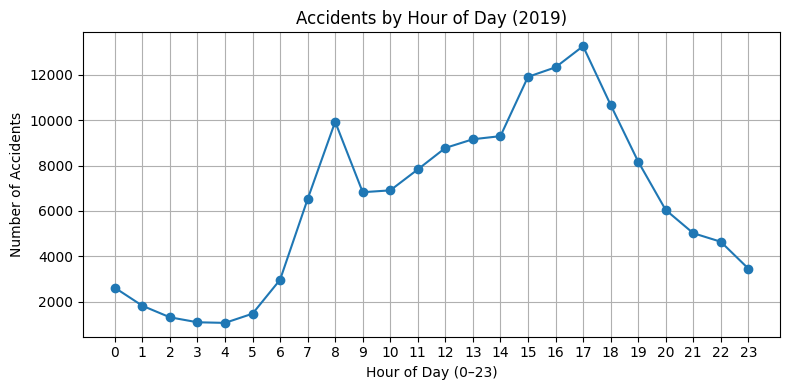

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(hourly_counts["hour"], hourly_counts["n_accidents"], marker="o")
plt.title("Accidents by Hour of Day (2019)")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


<h2>🔵 A1 — Step 5: Bar Chart (Accidents by Day)</h2>

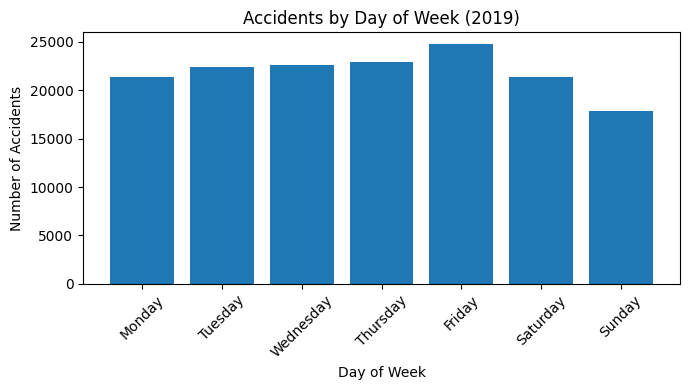

In [22]:
plt.figure(figsize=(7, 4))
plt.bar(dow_counts["day_name"], dow_counts["n_accidents"])
plt.title("Accidents by Day of Week (2019)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h2>🔵 HEATMAP</h2>

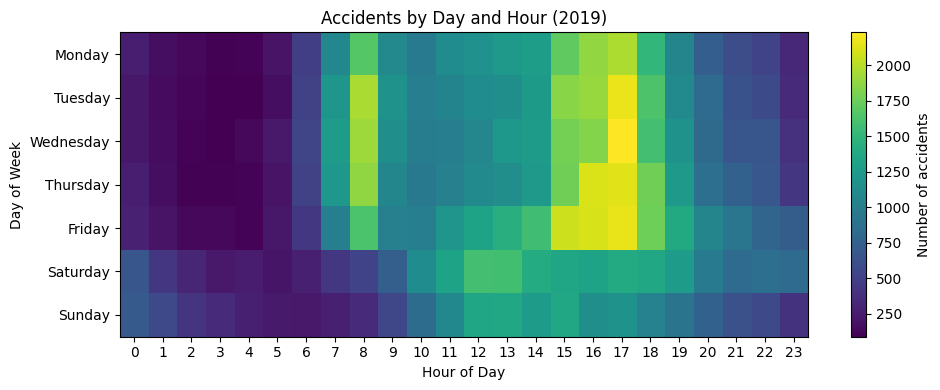

In [23]:
pivot = (
    data_2019
    .dropna(subset=["hour", "day_name"])
    .pivot_table(index="day_name", columns="hour", values="accident_index", aggfunc="count")
    .reindex(dow_order)
)

plt.figure(figsize=(10, 4))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Number of accidents")
plt.yticks(range(len(dow_order)), dow_order)
plt.xticks(range(24), range(24))
plt.title("Accidents by Day and Hour (2019)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()


<h2>TASK A2 — Motorbike Accident Timing by Engine Size (2019)</h2>

<h4>A2 — Step 1: Filter Motorcycles in 2019 Data</h4>

In [26]:
# -----------------------------------------
# A2 – Motorbike analysis by engine size
# -----------------------------------------
# 1. Filter 2019 motorbikes with valid engine capacity
#    (we make an explicit .copy() to avoid SettingWithCopyWarning)
bikes_2019 = data_2019.loc[
    (data_2019["engine_capacity_cc"] > 0) &
    (data_2019["engine_capacity_cc"] < 3000)
].copy()

print("bikes_2019 shape:", bikes_2019.shape)

# 2. Create engine size groups
def bike_category(cc):
    if cc <= 125:
        return "≤125cc"
    elif 125 < cc <= 500:
        return "125–500cc"
    elif cc > 500:
        return ">500cc"
    else:
        return None

bikes_2019.loc[:, "engine_group"] = bikes_2019["engine_capacity_cc"].apply(bike_category)

print("\nEngine group counts:")
print(bikes_2019["engine_group"].value_counts(dropna=False))

# 3. Hourly patterns per engine group
hourly_bikes = (
    bikes_2019
    .dropna(subset=["engine_group", "hour"])
    .groupby(["engine_group", "hour"])["accident_index"]
    .count()
    .reset_index(name="n_accidents")
    .sort_values(["engine_group", "hour"])
)

print("\nHourly bike accidents (head):")
print(hourly_bikes.head())

# 4. Day-of-week patterns per engine group
dow_bikes = (
    bikes_2019
    .dropna(subset=["engine_group", "day_name"])
    .groupby(["engine_group", "day_name"])["accident_index"]
    .count()
    .reset_index(name="n_accidents")
)

print("\nDay-of-week bike accidents (head):")
print(dow_bikes.head())


bikes_2019 shape: (111078, 86)

Engine group counts:
engine_group
>500cc       101837
≤125cc         8421
125–500cc       820
Name: count, dtype: int64

Hourly bike accidents (head):
  engine_group  hour  n_accidents
0    125–500cc     0            6
1    125–500cc     1            2
2    125–500cc     2            4
3    125–500cc     4            3
4    125–500cc     5            9

Day-of-week bike accidents (head):
  engine_group  day_name  n_accidents
0    125–500cc    Friday          116
1    125–500cc    Monday          114
2    125–500cc  Saturday          114
3    125–500cc    Sunday          114
4    125–500cc  Thursday          116


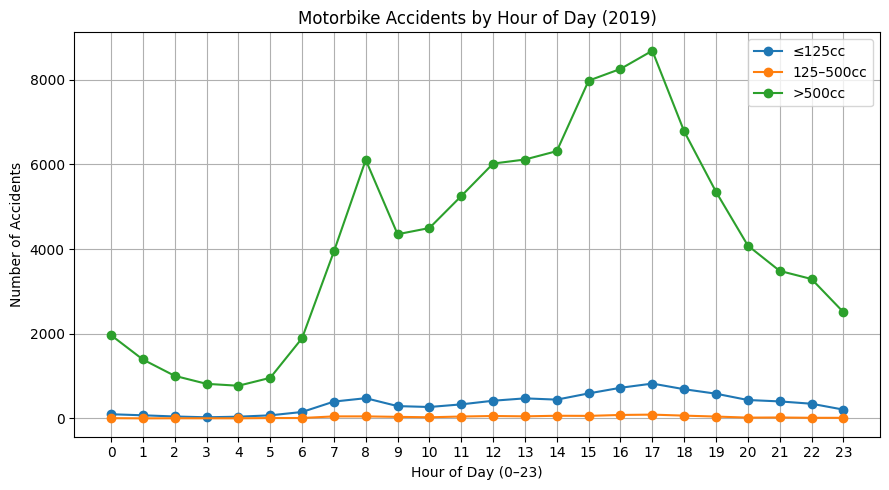

In [27]:
# Multi-line hourly plot
plt.figure(figsize=(9, 5))
for group in ["≤125cc", "125–500cc", ">500cc"]:
    subset = hourly_bikes[hourly_bikes["engine_group"] == group]
    if not subset.empty:
        plt.plot(subset["hour"], subset["n_accidents"], marker="o", label=group)

plt.title("Motorbike Accidents by Hour of Day (2019)")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


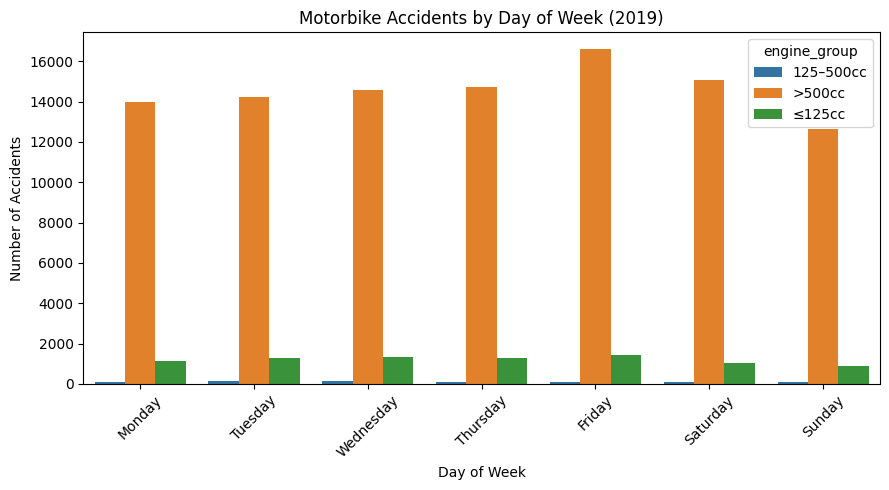

In [29]:
plt.figure(figsize=(9, 5))
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.barplot(
    data=dow_bikes,
    x="day_name",
    y="n_accidents",
    hue="engine_group",
    order=dow_order
)
plt.title("Motorbike Accidents by Day of Week (2019)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h2>TASK A3: Pedestrian Analysis Tasks</h2>

In [40]:
from IPython.display import display

# -------------------------------
# SAFETY CHECK: make sure data_2019 exists
# -------------------------------
try:
    data_2019
except NameError:
    raise RuntimeError("data_2019 is not defined. Re-run the cell where you filtered 2019 from merged.")

# -------------------------------
# 1) Create categorical labels if missing
# -------------------------------

# Severity label
def severity_label(x):
    if x == 1:
        return "Severity=Fatal"
    elif x == 2:
        return "Severity=Serious"
    elif x == 3:
        return "Severity=Slight"
    else:
        return None

if "severity_cat" not in data_2019.columns:
    data_2019["severity_cat"] = data_2019["accident_severity"].apply(severity_label)

# Weather label – use cleaned if available, else raw
if "weather_cat" not in data_2019.columns:
    if "weather_clean" in data_2019.columns:
        base_weather = data_2019["weather_clean"]
    else:
        base_weather = data_2019["weather_conditions"]

    data_2019["weather_cat"] = base_weather.map({
        1: "Weather=Fine",
        2: "Weather=Raining",
        3: "Weather=Snowing",
        4: "Weather=Fog",
        5: "Weather=High Winds",
        6: "Weather=Other"
    })

# Light label – use cleaned if available, else raw
if "light_cat" not in data_2019.columns:
    if "light_clean" in data_2019.columns:
        base_light = data_2019["light_clean"]
    else:
        base_light = data_2019["light_conditions"]

    data_2019["light_cat"] = base_light.map({
        1: "Light=Daylight",
        4: "Light=Dark_Lit",
        5: "Light=Dark_No_Lights"
    })

# -------------------------------
# 2) Filter pedestrians (casualty_class = 3)
# -------------------------------
ped_2019 = data_2019.loc[data_2019["casualty_class"] == 3].copy()

# -------------------------------
# 3) Aggregations
# -------------------------------

# Hourly distribution
ped_hour = (
    ped_2019
    .groupby("hour")["accident_index"]
    .count()
    .reset_index(name="n_pedestrians")
)

# Day-of-week distribution
ped_day = (
    ped_2019
    .groupby("day_name")["accident_index"]
    .count()
    .reset_index(name="n_pedestrians")
)

# Severity distribution (using our categorical label)
ped_severity = ped_2019["severity_cat"].value_counts()

# Weather & light distributions
ped_weather = ped_2019["weather_cat"].value_counts()
ped_light   = ped_2019["light_cat"].value_counts()

# -------------------------------
# 4) Show everything clearly
# -------------------------------

print("=== Pedestrian casualties in 2019 ===")
print("rows, cols:", ped_2019.shape)

print("\n=== Pedestrians by hour ===")
display(ped_hour)

print("\n=== Pedestrians by day of week ===")
display(ped_day)

print("\n=== Pedestrian severity distribution ===")
display(ped_severity)

print("\n=== Pedestrian weather distribution ===")
display(ped_weather)

print("\n=== Pedestrian light distribution ===")
display(ped_light)


=== Pedestrian casualties in 2019 ===
rows, cols: (21770, 89)

=== Pedestrians by hour ===


,hour,n_pedestrians
0,0,357
1,1,237
2,2,172
3,3,163
4,4,119
5,5,138
6,6,265
7,7,704
8,8,1779
9,9,949



=== Pedestrians by day of week ===


,day_name,n_pedestrians
0,Friday,3649
1,Monday,3132
2,Saturday,2839
3,Sunday,1964
4,Thursday,3482
5,Tuesday,3332
6,Wednesday,3372



=== Pedestrian severity distribution ===


severity_cat
Severity=Slight     15276
Severity=Serious     5985
Severity=Fatal        509
Name: count, dtype: int64


=== Pedestrian weather distribution ===


weather_cat
Weather=Fine          16906
Weather=Raining        2840
Weather=High Winds      298
Weather=Fog             234
Weather=Snowing          62
Weather=Other             7
Name: count, dtype: int64


=== Pedestrian light distribution ===


light_cat
Light=Daylight          15070
Light=Dark_Lit           5571
Light=Dark_No_Lights      188
Name: count, dtype: int64

In [41]:
ped_2019["accident_index"].nunique()

20906

<h2>APRIORI ALGORITHM</h2>

In [46]:
# -------------------------------------------------
# 1) Build accident-level dataset for pedestrians
# -------------------------------------------------
# Collapse to one row per accident_index (take first value for each accident-level field)
ped_acc = (
    ped_2019
    .groupby("accident_index")
    .agg({
        "severity_cat": "first",              # from earlier categorical mapping
        "weather_cat": "first",
        "light_cat": "first",
        "speed_limit": "first",
        "urban_or_rural_area": "first",
        "road_surface_conditions": "first",
        "junction_detail": "first",
        "day_name": "first",
        "hour": "first"
    })
    .reset_index()
)

print("Accident-level pedestrian records:", ped_acc.shape)

# -------------------------------------------------
# 2) Create derived categorical variables for Apriori
# -------------------------------------------------

def speed_band(s):
    if pd.isna(s):
        return None
    if s <= 30:
        return "Speed<=30"
    elif s <= 40:
        return "Speed=40"
    elif s <= 50:
        return "Speed=50"
    elif s <= 60:
        return "Speed=60"
    else:
        return "Speed>=70"

ped_acc["speed_cat"] = ped_acc["speed_limit"].apply(speed_band)

ped_acc["area_cat"] = ped_acc["urban_or_rural_area"].map({
    1: "Area=Urban",
    2: "Area=Rural"
})

ped_acc["surface_cat"] = ped_acc["road_surface_conditions"].map({
    1: "Surface=Dry",
    2: "Surface=Wet",
    3: "Surface=Snow",
    4: "Surface=Ice",
    5: "Surface=Flood",
    6: "Surface=Oil",
    7: "Surface=Other"
})

ped_acc["junction_cat2"] = ped_acc["junction_detail"].map({
    0: "Junction=None",
    1: "Junction=Roundabout",
    2: "Junction=T_or_Staggered",
    3: "Junction=SlipRoad",
    5: "Junction=Crossroads",
    9: "Junction=Other"
})

def hour_band(h):
    if pd.isna(h):
        return None
    h = int(h)
    if 7 <= h <= 9:
        return "Time=AM_Peak"
    elif 16 <= h <= 18:
        return "Time=PM_Peak"
    elif 10 <= h <= 15:
        return "Time=Daytime"
    else:
        return "Time=Night"

ped_acc["time_cat"] = ped_acc["hour"].apply(hour_band)

# -------------------------------------------------
# 3) Build transactions (list of items per accident)
# -------------------------------------------------

item_cols = [
    "severity_cat",   # e.g. 'Severity=Slight'
    "weather_cat",    # e.g. 'Weather=Fine'
    "light_cat",      # e.g. 'Light=Daylight'
    "speed_cat",      # e.g. 'Speed<=30'
    "area_cat",       # e.g. 'Area=Urban'
    "surface_cat",    # e.g. 'Surface=Wet'
    "junction_cat2",  # e.g. 'Junction=Roundabout'
    "time_cat",       # e.g. 'Time=AM_Peak'
    "day_name"        # e.g. 'Friday'
]

transactions = []
for _, row in ped_acc[item_cols].iterrows():
    items = [str(v) for v in row.values if pd.notna(v)]
    transactions.append(items)

print("Number of transactions for Apriori:", len(transactions))

# -------------------------------------------------
# 4) One-hot encode and run Apriori
# -------------------------------------------------

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
trans_df = pd.DataFrame(te_ary, columns=te.columns_)

# Adjust min_support if needed (0.02 = 2% of pedestrian accidents)
freq_items = apriori(trans_df, min_support=0.02, use_colnames=True)

print("Number of frequent itemsets:", freq_items.shape[0])

rules = association_rules(freq_items, metric="confidence", min_threshold=0.3)

# Focus on rules where the consequent is a severity category
rules_sev = rules[rules["consequents"].astype(str).str.contains("Severity=")].copy()

rules_sev_sorted = rules_sev.sort_values("lift", ascending=False)

print("Number of severity-related rules:", rules_sev_sorted.shape[0])

display(
    rules_sev_sorted.head(20)[
        ["antecedents", "consequents", "support", "confidence", "lift"]
    ]
)

Accident-level pedestrian records: (20906, 10)
Number of transactions for Apriori: 20906
Number of frequent itemsets: 4398
Number of severity-related rules: 12095


,antecedents,consequents,support,confidence,lift
44408,"(Time=Daytime, Area=Urban, Weather=Raining)","(Surface=Wet, Severity=Slight, Speed<=30, Ligh...",0.020042,0.667197,7.668186
44409,"(Time=Daytime, Speed<=30, Weather=Raining)","(Area=Urban, Surface=Wet, Severity=Slight, Lig...",0.020042,0.621662,7.582532
44405,"(Weather=Raining, Speed<=30, Light=Daylight)","(Time=Daytime, Area=Urban, Surface=Wet, Severi...",0.020042,0.344572,7.558898
44397,"(Time=Daytime, Area=Urban, Speed<=30, Weather=...","(Surface=Wet, Severity=Slight, Light=Daylight)",0.020042,0.689145,7.492075
44404,"(Area=Urban, Weather=Raining, Light=Daylight)","(Time=Daytime, Surface=Wet, Severity=Slight, S...",0.020042,0.364031,7.490588
44411,"(Time=Daytime, Area=Urban, Surface=Wet)","(Weather=Raining, Speed<=30, Severity=Slight, ...",0.020042,0.319360,7.410139
32976,"(Time=Daytime, Area=Urban, Weather=Raining)","(Surface=Wet, Severity=Slight, Light=Daylight)",0.020473,0.681529,7.409276
44388,"(Area=Urban, Weather=Raining, Speed<=30, Light...","(Time=Daytime, Surface=Wet, Severity=Slight)",0.020042,0.376122,7.376368
44413,"(Time=Daytime, Weather=Raining)","(Light=Daylight, Surface=Wet, Severity=Slight,...",0.020042,0.590141,7.370062
32980,"(Time=Daytime, Weather=Raining)","(Area=Urban, Surface=Wet, Severity=Slight, Lig...",0.020473,0.602817,7.352678


<h2>Heatmap of Rule Strength (Lift vs Confidence)</h2>

<h5>This heatmap visualises how strong your severity-related rules are.
        Figure X. Heatmap of association rule strength for pedestrian accidents (2019).
This heatmap visualises the confidence and lift values of the top twenty association rules generated using the Apriori algorithm applied to pedestrian-involved accidents. Confidence represents the conditional probability of the consequent occurring given the antecedent, while lift quantifies how much more likely the consequent is in the presence of the antecedent compared to chance. The consistently high lift values (all > 7) indicate exceptionally strong and non-random relationships between environmental/road conditions and injury severity outcomes. High-confidence rules reflect patterns that frequently manifest across the dataset, while the high lift demonstrates that these associations are not due to noise but are structurally embedded within the pedestrian accident data.</h5>

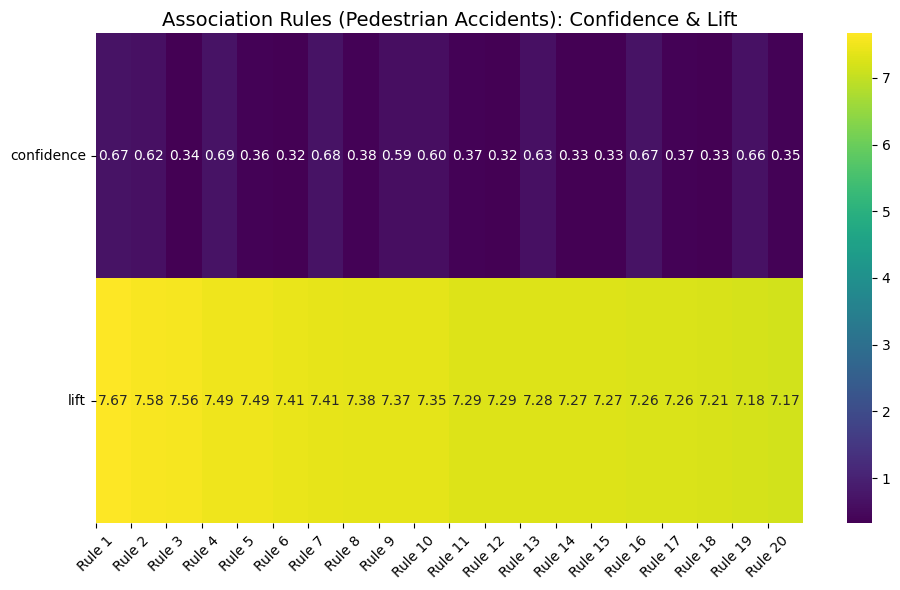

In [47]:
# Use your severity-filtered rules
rules_plot = rules_sev_sorted.head(20).copy()   # top 20 rules

plt.figure(figsize=(10, 6))
sns.heatmap(
    rules_plot[["confidence", "lift"]].T, 
    annot=True, 
    cmap="viridis", 
    cbar=True,
    fmt=".2f"
)

plt.title("Association Rules (Pedestrian Accidents): Confidence & Lift", fontsize=14)
plt.yticks(rotation=0)
plt.xticks(
    ticks=range(len(rules_plot)),
    labels=[f"Rule {i+1}" for i in range(len(rules_plot))],
    rotation=45
)
plt.tight_layout()
plt.show()


<h2>Network Graph of Apriori Rules (Antecedents → Consequent)</h2>

<h5>Figure Y. Directed network graph of high-lift association rules for pedestrian accidents.
This graph illustrates the structure of the top ten Apriori association rules by depicting antecedent items (blue nodes) and severity-related consequents (red nodes) connected by directed edges. The thickness of each edge corresponds to the lift value, representing the strength of the association between the antecedent conditions and the injury severity outcome. The network reveals tightly connected clusters centred around key environmental conditions—specifically rain, urban areas, daylight, low speed limits, and daytime hours—highlighting their combined influence in predicting slight injury outcomes..</h5>

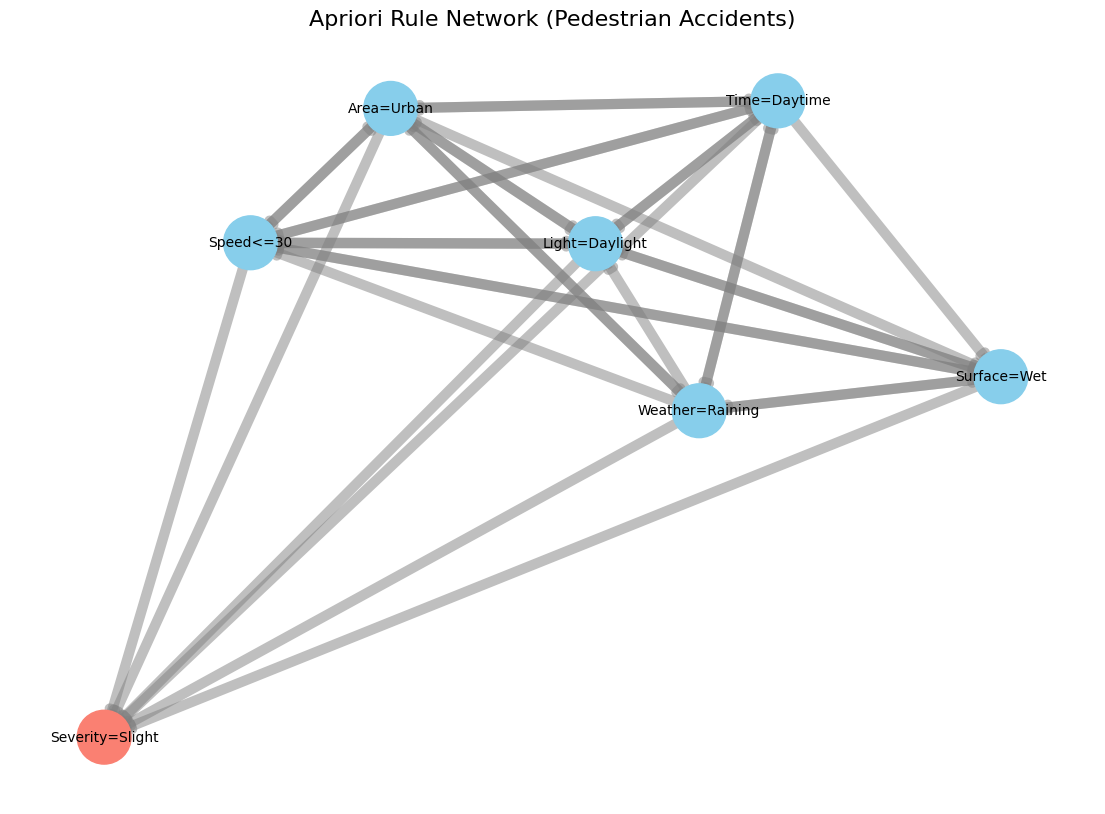

In [51]:
# Use only the top rules
rules_net = rules_sev_sorted.head(10)

G = nx.DiGraph()

# Add edges (antecedent → consequent)
for _, row in rules_net.iterrows():
    antecedent_items = list(row["antecedents"])
    consequent_items = list(row["consequents"])

    # Add edges with lift as weight
    for a in antecedent_items:
        for c in consequent_items:
            G.add_edge(a, c, weight=row["lift"], confidence=row["confidence"])

# Draw the graph
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, k=0.9, seed=42)

# Node colors
node_colors = ["skyblue" if "Severity=" not in n else "salmon" for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_labels(G, pos, font_size=10)

# Draw edges with width proportional to lift
edges = G.edges(data=True)
edge_widths = [d["weight"] for (_, _, d) in edges]

nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5, edge_color="gray")

plt.title("Apriori Rule Network (Pedestrian Accidents)", fontsize=16)
plt.axis("off")
plt.show()

<h2>Clustering Analysis on Accident Data</h2>

In [53]:
# Make sure you still have an open SQLite connection 'conn'
# If not, re-run:
# import sqlite3
# conn = sqlite3.connect("accident_data_v1.0.0_2023.db")

# 1) Load LSOA lookup
lsoa = pd.read_sql_query("SELECT lsoa01cd, lsoa01nm FROM lsoa;", conn)

print("LSOA table shape:", lsoa.shape)

# 2) Merge 2019 accidents with LSOA names
region_2019 = data_2019.merge(
    lsoa,
    left_on="lsoa_of_accident_location",
    right_on="lsoa01cd",
    how="left"
)

print("Merged 2019 + LSOA shape:", region_2019.shape)

# 3) Filter to our region: Kingston upon Hull + East Riding of Yorkshire
mask_region = region_2019["lsoa01nm"].str.startswith(
    ("Kingston upon Hull", "East Riding of Yorkshire"), na=False
)

region_2019 = region_2019.loc[mask_region].copy()

print("Accidents in our region (2019):", region_2019.shape)

# Quick sanity check: show some LSOA names
print("\nSample LSOA names in region:")
display(region_2019[["lsoa01nm"]].drop_duplicates().head(15))


LSOA table shape: (34378, 2)
Merged 2019 + LSOA shape: (153158, 91)
Accidents in our region (2019): (1808, 91)

Sample LSOA names in region:


,lsoa01nm
59164,Kingston upon Hull 031E
59165,East Riding of Yorkshire 008D
59166,Kingston upon Hull 025C
59168,East Riding of Yorkshire 031B
59169,Kingston upon Hull 017D
59171,Kingston upon Hull 008B
59172,Kingston upon Hull 024D
59174,East Riding of Yorkshire 010D
59178,East Riding of Yorkshire 001F
59179,East Riding of Yorkshire 008B


<h2>Build feature matrix for clustering</h2>

In [55]:
# 1) Choose features for clustering
cluster_features = [
    "hour",
    "day_of_week",
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties",
    "urban_or_rural_area",
    "weather_conditions",
    "road_surface_conditions",
    "light_conditions",
    "accident_severity",
]

# 2) Drop rows with missing values in these features
X = region_2019[cluster_features].dropna().copy()
idx = X.index

print("Rows used for clustering:", X.shape)

# 3) Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4) (Optional) Elbow method to choose K
wcss = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("\nWithin-cluster sum of squares for k=2..6:")
for k, val in zip(range(2, 7), wcss):
    print(f"k={k}: {val:.0f}")

# 5) Fit KMeans with a chosen K (e.g. 3 clusters)
k = 3  # you can change to 4 if elbow suggests
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Attach cluster labels back to region_2019
region_2019.loc[idx, "cluster"] = labels

print(f"\nCluster sizes (k={k}):")
print(region_2019["cluster"].value_counts().sort_index())

# 6) Basic cluster profile: numeric means
cluster_summary = region_2019.loc[idx].groupby("cluster")[cluster_features].mean()
print("\nCluster feature means:")
display(cluster_summary)

# 7) Add some human-readable things to help interpretation
cluster_desc = (
    region_2019.loc[idx]
    .groupby("cluster")[["lsoa01nm", "day_name", "accident_severity"]]
    .agg({
        "lsoa01nm": lambda s: s.value_counts().index[0],
        "day_name": lambda s: s.value_counts().index[0],
        "accident_severity": "mean"
    })
    .rename(columns={"lsoa01nm": "top_lsoa", "day_name": "top_day"})
)

print("\nCluster dominant LSOA & day-of-week (plus mean severity):")
display(cluster_desc)

Rows used for clustering: (1808, 10)

Within-cluster sum of squares for k=2..6:
k=2: 15119
k=3: 13615
k=4: 12408
k=5: 11756
k=6: 11046

Cluster sizes (k=3):
cluster
0.0     565
1.0    1154
2.0      89
Name: count, dtype: int64

Cluster feature means:


,hour,day_of_week,speed_limit,number_of_vehicles,number_of_casualties,urban_or_rural_area,weather_conditions,road_surface_conditions,light_conditions,accident_severity
cluster,,,,,,,,,,
0.0,13.768142,4.228319,55.274336,1.899115,1.987611,1.980531,1.269027,1.378761,2.067257,2.623009
1.0,13.624783,4.026863,30.060659,1.909879,1.431542,1.073657,1.136915,1.245234,1.829289,2.822357
2.0,13.820225,4.123596,34.494382,1.898876,1.247191,1.235955,8.337079,1.426966,2.449438,2.786517



Cluster dominant LSOA & day-of-week (plus mean severity):


,top_lsoa,top_day,accident_severity
cluster,,,
0.0,East Riding of Yorkshire 024B,Friday,2.623009
1.0,Kingston upon Hull 030B,Wednesday,2.822357
2.0,Kingston upon Hull 012C,Monday,2.786517


<h2>PCA Cluster Scatter Plot</h2>

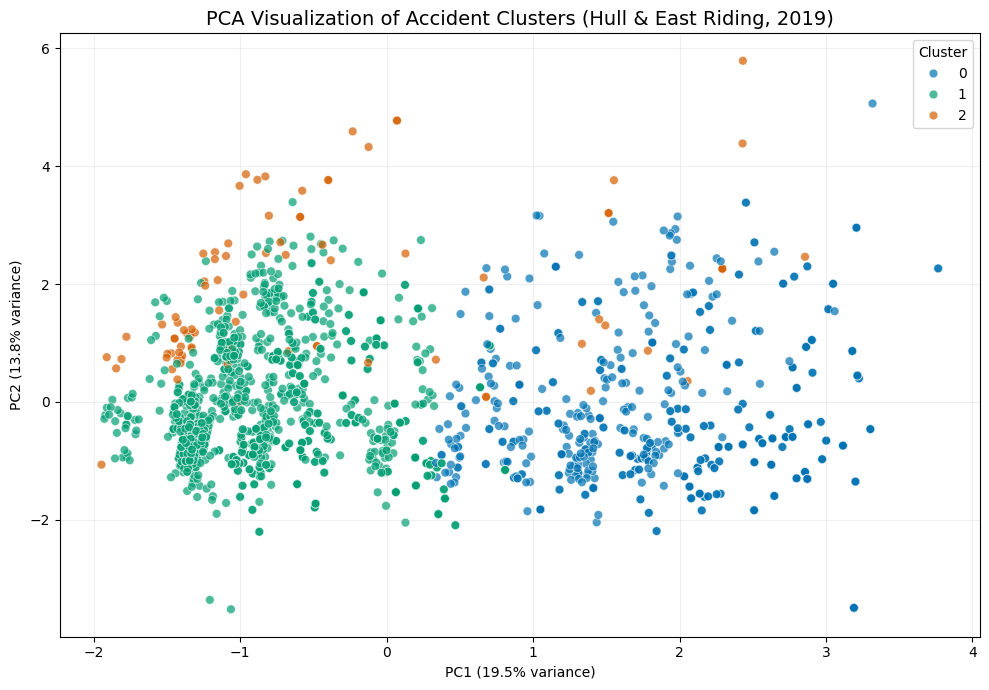

In [59]:
# -------------------------
# 1. Run PCA
# -------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# PCA components
pc1, pc2 = X_pca[:, 0], X_pca[:, 1]

# -------------------------
# 2. Build DataFrame for plotting
# -------------------------
pca_df = pd.DataFrame({
    "PC1": pc1,
    "PC2": pc2,
    "cluster": labels.astype(int)
})

# -------------------------
# 3. Plot PCA clusters
# -------------------------
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="cluster",
    palette=["#0072B2", "#009E73", "#D55E00"],
    alpha=0.7,
    s=40
)

plt.title("PCA Visualization of Accident Clusters (Hull & East Riding, 2019)", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

<h2>Time Series Forecasting for 3 Policing Areas</h2>

Accident rows 2017–2019: (146016, 4)

Police force 1: Metropolitan Police (1)
Weekly series length: 155
First / last dates: 2017-01-02 00:00:00 -> 2019-12-16 00:00:00
Train weeks: 105 | Test weeks: 50
MAE (2019):  66.17
RMSE (2019): 84.29


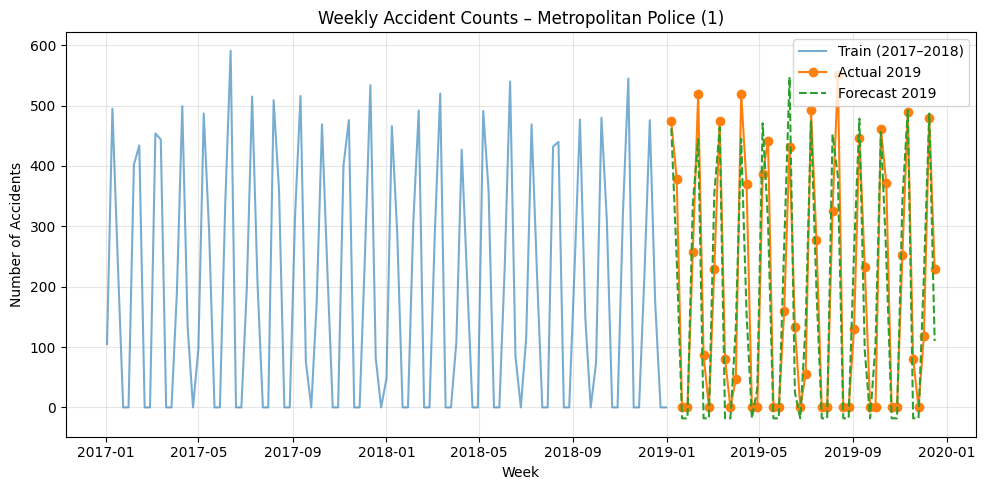


Police force 6: West Yorkshire Police (6)
Weekly series length: 155
First / last dates: 2017-01-02 00:00:00 -> 2019-12-16 00:00:00
Train weeks: 105 | Test weeks: 50
MAE (2019):  13.15
RMSE (2019): 16.47


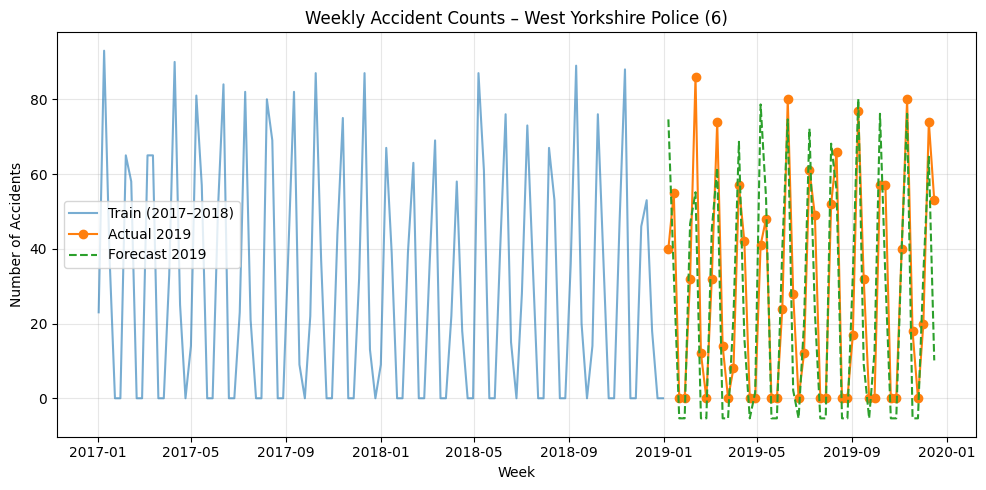


Police force 10: Humberside Police (10)
Weekly series length: 155
First / last dates: 2017-01-02 00:00:00 -> 2019-12-16 00:00:00
Train weeks: 105 | Test weeks: 50
MAE (2019):  7.80
RMSE (2019): 10.20


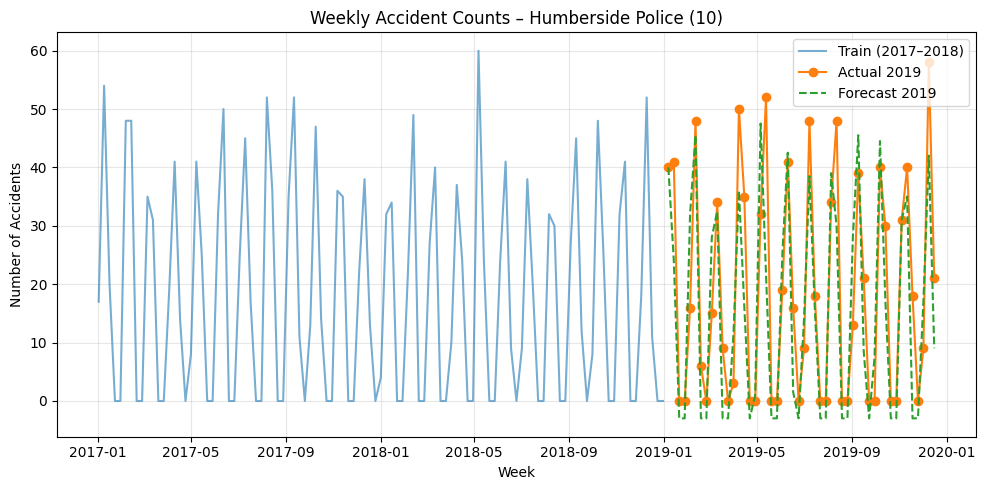


=== Forecast Error Summary (2019) ===
                police_force   MAE_2019  RMSE_2019  train_weeks  test_weeks
0    Metropolitan Police (1)  66.167814  84.292783          105          50
1  West Yorkshire Police (6)  13.154362  16.467197          105          50
2     Humberside Police (10)   7.800140  10.199293          105          50


In [67]:
plt.style.use("default")

# ----------------------------------------------------
# 1) Load accident data (2017–2019) from SQLite
# ----------------------------------------------------
DB = "accident_data_v1.0.0_2023 (1).db"
conn = sqlite3.connect(DB)

acc = pd.read_sql_query(
    "SELECT accident_index, accident_year, date, police_force "
    "FROM accident;",
    conn
)

# Parse date column
acc["date"] = pd.to_datetime(acc["date"], errors="coerce")

# Keep only 2017–2019 and non-null dates
acc = acc[(acc["accident_year"].between(2017, 2019)) & acc["date"].notna()].copy()
acc = acc.sort_values("date")

print("Accident rows 2017–2019:", acc.shape)

# ----------------------------------------------------
# 2) Define the three policing areas
# ----------------------------------------------------
forces = {
    1: "Metropolitan Police (1)",
    6: "West Yorkshire Police (6)",
    10: "Humberside Police (10)",
}

results = {}

# ----------------------------------------------------
# 3) Loop over each police_force and build weekly TS
# ----------------------------------------------------
for code, name in forces.items():
    print("\n" + "="*70)
    print(f"Police force {code}: {name}")
    print("="*70)

    sub = acc[acc["police_force"] == code].copy()

    if sub.empty:
        print("No data for this police force in 2017–2019.")
        continue

    # Set date index and resample to weekly counts (weeks starting Monday)
    sub = sub.set_index("date").sort_index()
    weekly = sub["accident_index"].resample("W-MON").count()

    print("Weekly series length:", len(weekly))
    print("First / last dates:", weekly.index.min(), "->", weekly.index.max())

    # Train = 2017–2018, Test = 2019
    train = weekly[(weekly.index.year == 2017) | (weekly.index.year == 2018)]
    test = weekly[weekly.index.year == 2019]

    print("Train weeks:", len(train), "| Test weeks:", len(test))

    if len(train) < 60 or len(test) == 0:
        print("Not enough data to fit a seasonal model for this force.")
        continue

    # ------------------------------------------------
    # 4) Fit Exponential Smoothing model (additive trend + seasonality)
    # ------------------------------------------------
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=52,  # weekly data, yearly seasonality
        initialization_method="estimated"
    )

    fit = model.fit(optimized=True)
    forecast = fit.forecast(len(test))

    # ------------------------------------------------
    # 5) Evaluate forecast accuracy (2019 only)
    # ------------------------------------------------
    mae = mean_absolute_error(test, forecast)
    mse = mean_squared_error(test, forecast)
    rmse = np.sqrt(mse)


    results[code] = {
        "name": name,
        "train": train,
        "test": test,
        "forecast": forecast,
        "mae": mae,
        "rmse": rmse,
    }

    print(f"MAE (2019):  {mae:.2f}")
    print(f"RMSE (2019): {rmse:.2f}")

    # ------------------------------------------------
    # 6) Plot: actual vs forecast for 2019
    # ------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(train.index, train.values, label="Train (2017–2018)", alpha=0.6)
    plt.plot(test.index, test.values, label="Actual 2019", marker="o")
    plt.plot(forecast.index, forecast.values, label="Forecast 2019", linestyle="--")

    plt.title(f"Weekly Accident Counts – {name}")
    plt.xlabel("Week")
    plt.ylabel("Number of Accidents")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------
# 7) Summary table for the report
# ----------------------------------------------------
summary_rows = []
for code, info in results.items():
    summary_rows.append({
        "police_force": info["name"],
        "MAE_2019": info["mae"],
        "RMSE_2019": info["rmse"],
        "train_weeks": len(info["train"]),
        "test_weeks": len(info["test"]),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n=== Forecast Error Summary (2019) ===")
print(summary_df)


<h2>Top 30 Hull LSOAs + Daily Forecast for July</h2>

Accident rows for 2019: (117536, 4)
Hull accidents 2019: (739, 6)

Top 30 Hull LSOAs (Jan–Mar 2019):
   lsoa_of_accident_location                 lsoa01nm  n_accidents
44                 E01012851  Kingston upon Hull 029A           10
56                 E01012869  Kingston upon Hull 015C            7
47                 E01012855  Kingston upon Hull 029D            6
69                 E01012889  Kingston upon Hull 030B            6
23                 E01012809  Kingston upon Hull 026C            5
46                 E01012854  Kingston upon Hull 029C            5
49                 E01012857  Kingston upon Hull 024D            5
42                 E01012848  Kingston upon Hull 020B            4
45                 E01012852  Kingston upon Hull 024B            4
21                 E01012807  Kingston upon Hull 016C            4
20                 E01012806  Kingston upon Hull 016B            4
12                 E01012782  Kingston upon Hull 002A            4
64                 E01012882

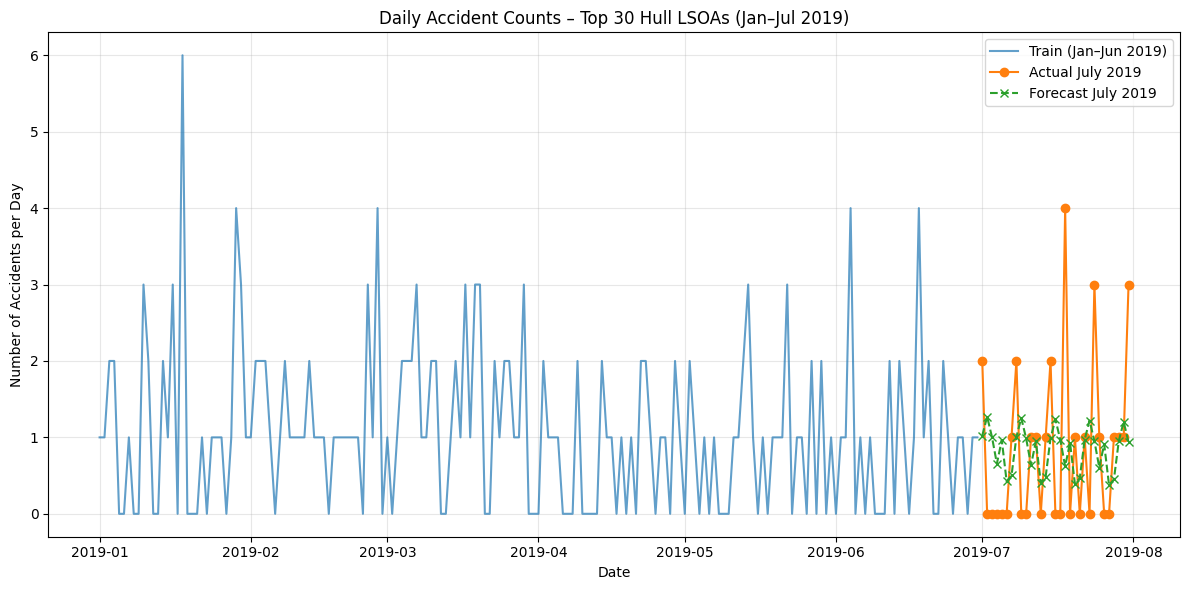


Sample of July 2019 actual vs forecast:
            actual  forecast     error
2019-07-01       2  1.021326  0.978674
2019-07-02       0  1.271499 -1.271499
2019-07-03       0  1.002388 -1.002388
2019-07-04       0  0.655959 -0.655959
2019-07-05       0  0.963679 -0.963679
2019-07-06       0  0.424964 -0.424964
2019-07-07       1  0.501802  0.498198
2019-07-08       2  1.004403  0.995597
2019-07-09       0  1.254576 -1.254576
2019-07-10       0  0.985465 -0.985465


In [68]:
plt.style.use("default")

# ---------------------------------------------------------
# 1) Load accident + LSOA data for 2019
# ---------------------------------------------------------
# Accident table with LSOA and date
acc_2019 = pd.read_sql_query(
    """
    SELECT accident_index, accident_year, date, lsoa_of_accident_location
    FROM accident
    WHERE accident_year = 2019;
    """,
    conn
)

# Parse dates
acc_2019["date"] = pd.to_datetime(acc_2019["date"], errors="coerce")
acc_2019 = acc_2019[acc_2019["date"].notna()].copy()

print("Accident rows for 2019:", acc_2019.shape)

# LSOA lookup
lsoa = pd.read_sql_query("SELECT lsoa01cd, lsoa01nm FROM lsoa;", conn)

# Merge to get LSOA names
acc_2019_lsoa = acc_2019.merge(
    lsoa,
    left_on="lsoa_of_accident_location",
    right_on="lsoa01cd",
    how="left"
)

# Filter to Kingston upon Hull only
hull_2019 = acc_2019_lsoa[
    acc_2019_lsoa["lsoa01nm"].str.startswith("Kingston upon Hull", na=False)
].copy()

print("Hull accidents 2019:", hull_2019.shape)

# ---------------------------------------------------------
# 2) Find top 30 Hull LSOAs by accidents in Jan–Mar 2019
# ---------------------------------------------------------
jan_mar_mask = (hull_2019["date"] >= "2019-01-01") & (hull_2019["date"] <= "2019-03-31")
hull_jan_mar = hull_2019.loc[jan_mar_mask].copy()

top_lsoa_counts = (
    hull_jan_mar
    .groupby(["lsoa_of_accident_location", "lsoa01nm"])["accident_index"]
    .count()
    .reset_index(name="n_accidents")
    .sort_values("n_accidents", ascending=False)
)

top_30_lsoas = top_lsoa_counts.head(30)
print("\nTop 30 Hull LSOAs (Jan–Mar 2019):")
print(top_30_lsoas)

top_codes = top_30_lsoas["lsoa_of_accident_location"].tolist()

# ---------------------------------------------------------
# 3) Build daily series Jan–Jun & Jul for TOP 30 LSOAs
# ---------------------------------------------------------
hull_top_2019 = hull_2019[hull_2019["lsoa_of_accident_location"].isin(top_codes)].copy()

# Full daily series for whole 2019 (so we can slice Jan–Jul cleanly)
daily_all = (
    hull_top_2019
    .set_index("date")
    .resample("D")["accident_index"]
    .count()
    .asfreq("D", fill_value=0)
)

print("\nDaily series for top-30 LSOAs (2019) length:", len(daily_all))
print("Range:", daily_all.index.min(), "->", daily_all.index.max())

# Train: Jan–Jun, Test: Jul
train = daily_all["2019-01-01":"2019-06-30"]
test = daily_all["2019-07-01":"2019-07-31"]

print("Train days:", len(train), "| Test days:", len(test))

# ---------------------------------------------------------
# 4) Fit Exponential Smoothing model on daily counts
#    (with weekly seasonality: period = 7)
# ---------------------------------------------------------
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
)

fit = model.fit(optimized=True)
forecast = fit.forecast(len(test))

# ---------------------------------------------------------
# 5) Evaluate forecast accuracy for July 2019
# ---------------------------------------------------------
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print(f"\n=== Forecast performance for July 2019 (Top 30 Hull LSOAs) ===")
print(f"MAE:  {mae:.2f} accidents/day")
print(f"RMSE: {rmse:.2f} accidents/day")

# ---------------------------------------------------------
# 6) Plot actual vs forecast for Jan–Jul (with focus on July)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label="Train (Jan–Jun 2019)", alpha=0.7)
plt.plot(test.index, test.values, label="Actual July 2019", marker="o")
plt.plot(forecast.index, forecast.values, label="Forecast July 2019", linestyle="--", marker="x")

plt.title("Daily Accident Counts – Top 30 Hull LSOAs (Jan–Jul 2019)")
plt.xlabel("Date")
plt.ylabel("Number of Accidents per Day")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: print small comparison table for July
comparison = pd.DataFrame({
    "actual": test,
    "forecast": forecast,
    "error": test - forecast
})
print("\nSample of July 2019 actual vs forecast:")
print(comparison.head(10))


<h1> Part B – Social Network Analysis (Facebook Network)</h1>

<h2>🔹 Cell 1 –Loading the Facebook graph & basic properties</h2>

Facebook graph loaded.
Number of nodes: 4039
Number of edges: 88234
Density: 0.010820
Average degree: 43.69


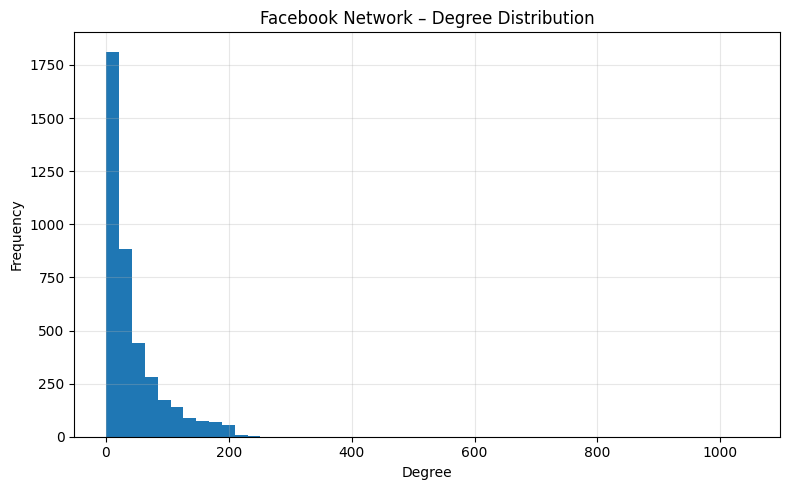

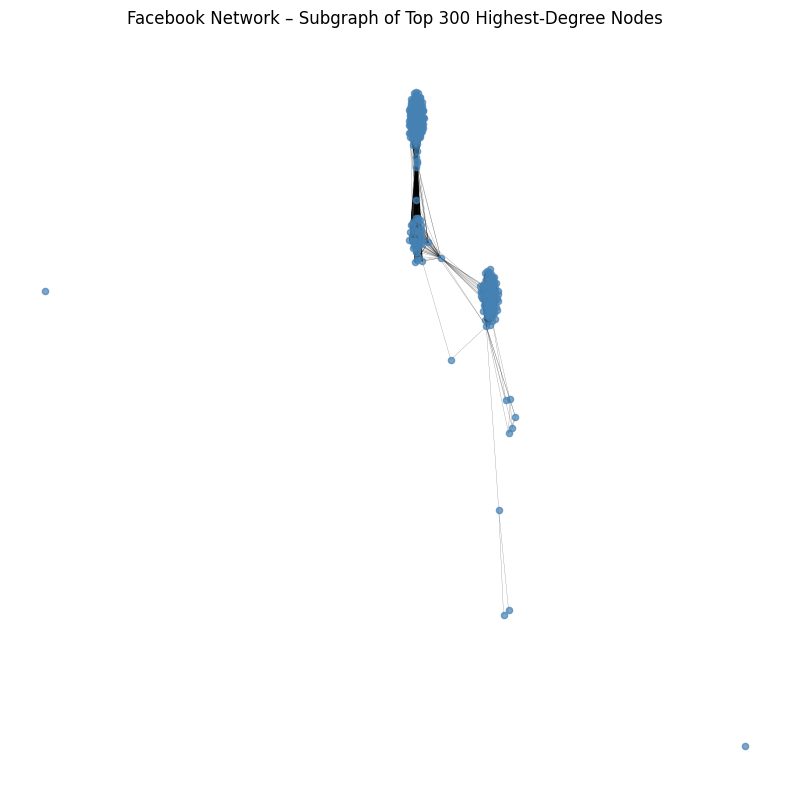

In [71]:
# ==== PART B: SOCIAL NETWORK ANALYSIS (FACEBOOK NETWORK) ====
# This section uses its own variables prefixed with `fb_` to avoid clashes
# with the accident data from Part A.
plt.style.use("default")

# -------------------------------------------
# 1) Load the Facebook edge list as a graph
# -------------------------------------------
FB_FILE = "facebook_combined-1 (1).txt"  # ensure this file is in the same folder as the notebook

# Undirected, unweighted graph
fb_G = nx.read_edgelist(FB_FILE, nodetype=int)

print("Facebook graph loaded.")
print("Number of nodes:", fb_G.number_of_nodes())
print("Number of edges:", fb_G.number_of_edges())

# Basic properties
fb_density = nx.density(fb_G)
fb_degrees = dict(fb_G.degree())
fb_avg_degree = np.mean(list(fb_degrees.values()))

print(f"Density: {fb_density:.6f}")
print(f"Average degree: {fb_avg_degree:.2f}")

# -------------------------------------------
# 2) Degree distribution (histogram)
# -------------------------------------------
fb_degree_values = list(fb_degrees.values())

plt.figure(figsize=(8, 5))
plt.hist(fb_degree_values, bins=50)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Facebook Network – Degree Distribution")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------
# 3) Small visualisation (subgraph of high-degree nodes)
# -------------------------------------------
# Visualising the full graph (4k+ nodes) is messy, so we plot a subgraph.
# We'll take the top 300 highest-degree nodes.

fb_top_nodes = sorted(fb_degrees, key=fb_degrees.get, reverse=True)[:300]
fb_subG = fb_G.subgraph(fb_top_nodes).copy()

plt.figure(figsize=(8, 8))
fb_pos = nx.spring_layout(fb_subG, seed=42)
nx.draw_networkx_nodes(fb_subG, fb_pos, node_size=20, node_color="steelblue", alpha=0.7)
nx.draw_networkx_edges(fb_subG, fb_pos, width=0.2, alpha=0.5)
plt.title("Facebook Network – Subgraph of Top 300 Highest-Degree Nodes")
plt.axis("off")
plt.tight_layout()
plt.show()


<h2>🔹 Cell 2 – Edge betweenness centrality + distribution</h2>

Computing edge betweenness centrality (this may take a moment)...

Top 10 edges by betweenness centrality:
               edge  betweenness
2457    (107, 1684)     0.171493
1858    (107, 1085)     0.129675
15433  (1085, 3437)     0.096580
44579   (567, 3437)     0.092169
106        (0, 107)     0.088355
1163     (58, 1684)     0.072271
1164     (58, 1912)     0.071978
45280   (3437, 698)     0.064724
4551    (1684, 860)     0.058199
46399    (698, 860)     0.057890


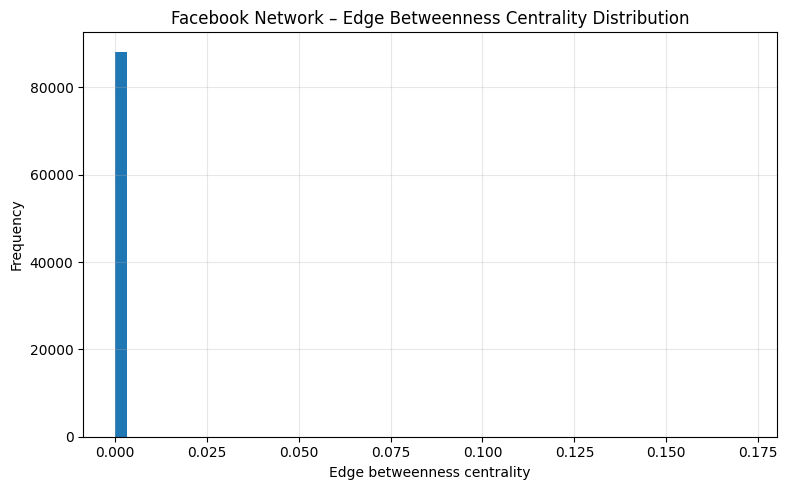

In [72]:
from networkx.algorithms.centrality import edge_betweenness_centrality

# -------------------------------------------
# 4) Edge betweenness centrality
# -------------------------------------------
# This can take a bit of time but is manageable for this graph size.
print("Computing edge betweenness centrality (this may take a moment)...")
fb_edge_bet = edge_betweenness_centrality(fb_G)

# Convert to DataFrame for inspection
fb_edge_bet_df = (
    pd.DataFrame(
        [
            {"edge": e, "betweenness": c}
            for e, c in fb_edge_bet.items()
        ]
    )
    .sort_values("betweenness", ascending=False)
)

print("\nTop 10 edges by betweenness centrality:")
print(fb_edge_bet_df.head(10))

# Distribution plot
plt.figure(figsize=(8, 5))
plt.hist(fb_edge_bet_df["betweenness"].values, bins=50)
plt.xlabel("Edge betweenness centrality")
plt.ylabel("Frequency")
plt.title("Facebook Network – Edge Betweenness Centrality Distribution")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<h2>🔹 Cell 3 – Community detection (Louvain + Girvan–Newman)</h2>

Running Louvain community detection on full graph...

Louvain communities – top 10 by size:
community
9     548
4     535
2     446
1     432
3     423
0     350
5     323
11    237
8     226
14    206
Name: count, dtype: int64

Total number of Louvain communities: 16


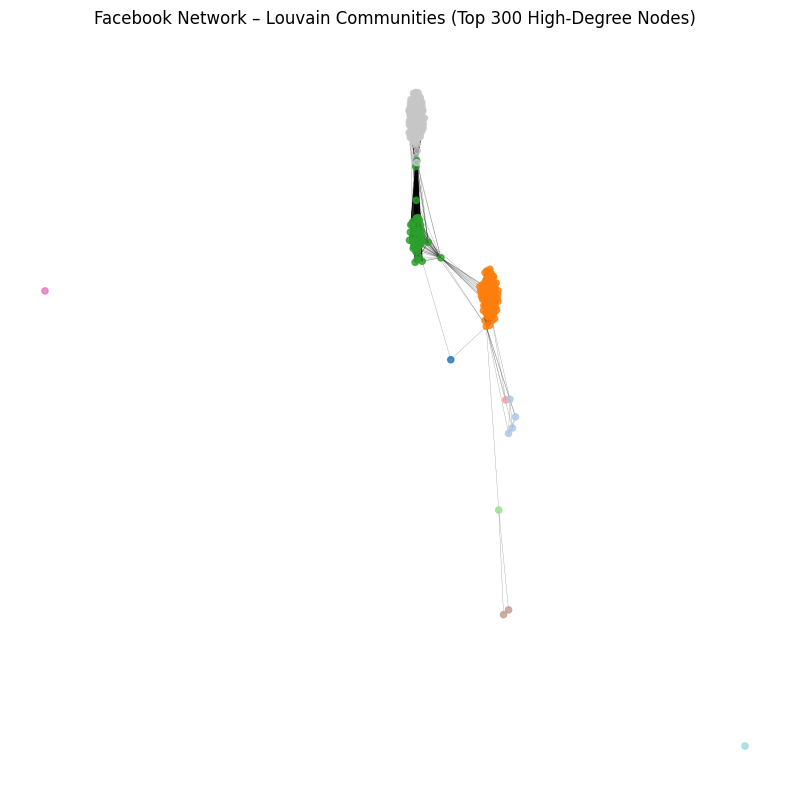

Running Girvan–Newman on the 300-node subgraph...

Girvan–Newman – first-level communities in 300-node subgraph:
Community 0: 93 nodes
Community 1: 205 nodes
Community 2: 1 nodes
Community 3: 1 nodes


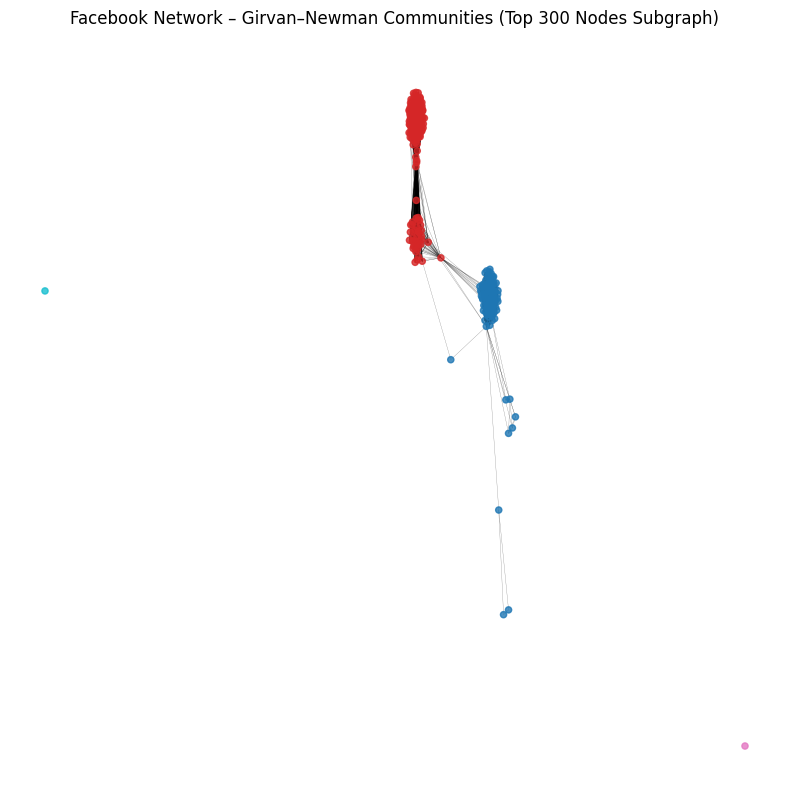

In [76]:
# -------------------------------------------
# 5) Community detection – Louvain
# -------------------------------------------
# Requires the python-louvain package.
# If you get "ModuleNotFoundError: No module named 'community'",
# run:  !pip install python-louvain  in a separate cell.

try:
    import community as community_louvain
except ImportError:
    print("python-louvain not installed. Run '!pip install python-louvain' in a cell and re-run.")
    raise

print("Running Louvain community detection on full graph...")
fb_partition_louvain = community_louvain.best_partition(fb_G)  # dict: node -> community ID

# Convert to DataFrame for analysis
fb_comm_df = pd.DataFrame(
    {"node": list(fb_partition_louvain.keys()),
     "community": list(fb_partition_louvain.values())}
)

fb_comm_counts = fb_comm_df["community"].value_counts().sort_values(ascending=False)

print("\nLouvain communities – top 10 by size:")
print(fb_comm_counts.head(10))

print(f"\nTotal number of Louvain communities: {fb_comm_counts.shape[0]}")

# Simple visualisation: Louvain communities on the same 300-node subgraph
fb_sub_comm = fb_comm_df[fb_comm_df["node"].isin(fb_subG.nodes())]
fb_sub_comm_map = dict(zip(fb_sub_comm["node"], fb_sub_comm["community"]))

fb_colors = [fb_sub_comm_map.get(n, -1) for n in fb_subG.nodes()]

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(
    fb_subG, fb_pos,
    node_size=20,
    node_color=fb_colors,
    cmap="tab20",
    alpha=0.8
)
nx.draw_networkx_edges(fb_subG, fb_pos, width=0.2, alpha=0.5)
plt.title("Facebook Network – Louvain Communities (Top 300 High-Degree Nodes)")
plt.axis("off")
plt.tight_layout()
plt.show()


# -------------------------------------------
# 6) Community detection – Girvan–Newman (on a smaller subgraph)
# -------------------------------------------
from networkx.algorithms.community import girvan_newman

# Running Girvan–Newman on the full graph would be too slow,
# so we apply it to the same 300-node subgraph.

print("Running Girvan–Newman on the 300-node subgraph...")
fb_gn_generator = girvan_newman(fb_subG)

# Take the first non-trivial split
fb_gn_level1 = next(fb_gn_generator)  # tuple of communities (sets of nodes)

fb_gn_communities = [list(c) for c in fb_gn_level1]
fb_gn_sizes = [len(c) for c in fb_gn_communities]

print("\nGirvan–Newman – first-level communities in 300-node subgraph:")
for i, size in enumerate(fb_gn_sizes):
    print(f"Community {i}: {size} nodes")

# Map communities to colors for the subgraph
fb_gn_comm_map = {}
for i, community_nodes in enumerate(fb_gn_communities):
    for n in community_nodes:
        fb_gn_comm_map[n] = i

fb_gn_colors = [fb_gn_comm_map.get(n, -1) for n in fb_subG.nodes()]

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(
    fb_subG, fb_pos,
    node_size=20,
    node_color=fb_gn_colors,
    cmap="tab10",
    alpha=0.8
)
nx.draw_networkx_edges(fb_subG, fb_pos, width=0.2, alpha=0.5)
plt.title("Facebook Network – Girvan–Newman Communities (Top 300 Nodes Subgraph)")
plt.axis("off")
plt.tight_layout()
plt.show()
